In [1]:
import pandas as pd
import numpy as np
import datetime
import GHEtool as ghe
from matplotlib import pyplot as plt
import sys
module_path = r"C:\Workdir\Develop\IOCS"
if module_path not in sys.path:
    sys.path.append(module_path)
from COP_tables import COP
import load_params
from borefield_modeling import Borefield

In [2]:
def read_ocp_result(path_outputsAll, path_OutputNames):
    column_names = pd.read_csv(path_OutputNames, header=None)
    column_names = column_names[0].tolist()
    column_names = ["time"] + column_names  # Assuming your time column is named "time"

    df = pd.read_csv(path_outputsAll, comment="#", skiprows=0, sep="\t", header=None, names=column_names)
    df = df.iloc[1:]
    df = df.astype(float)

    start_date = datetime.datetime(2023, 1, 1)  # Set your desired start date
    df["datetime"] = [start_date + datetime.timedelta(seconds=time) for time in df["time"]]
    df["hours"] = [ datetime.timedelta(seconds=time).total_seconds() / 3600 for time in df["time"]]
    df["days"] = [datetime.timedelta(seconds=time).total_seconds() / 86400 for time in df["time"]]

    return df



In [ ]:
path_outputsAll = r'C:\Users\u0148284\Downloads\outputsAll.csv'
path_OutputNames = r'C:\Users\u0148284\Downloads\OutputNames.csv'
ideal_ocp_df = read_ocp_result(path_outputsAll, path_OutputNames)

QDemHea = ideal_ocp_df["QDemHea"].to_numpy()
QDemCoo = ideal_ocp_df["QDemCoo"].to_numpy()
ElecDem = ideal_ocp_df["ElecDem"].to_numpy()




C:\Users\u0148284\AppData\Local\Temp\ipykernel_684\1399280976.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path_outputsAll, comment="#", skiprows=0, sep="\t", header=None, names=column_names)


Cluster design days...
Set parameter Username


2025-01-13 17:11:12 - gurobipy - INFO - Set parameter Username (k_medoids.py:53)


Academic license - for non-commercial use only - expires 2026-01-09


2025-01-13 17:11:12 - gurobipy - INFO - Academic license - for non-commercial use only - expires 2026-01-09 (k_medoids.py:53)


Set parameter TimeLimit to value 300


2025-01-13 17:11:22 - gurobipy - INFO - Set parameter TimeLimit to value 300 (k_medoids.py:94)


Set parameter MIPGap to value 0.02


2025-01-13 17:11:22 - gurobipy - INFO - Set parameter MIPGap to value 0.02 (k_medoids.py:95)


Design day clustering finished. (11.16361117362976)



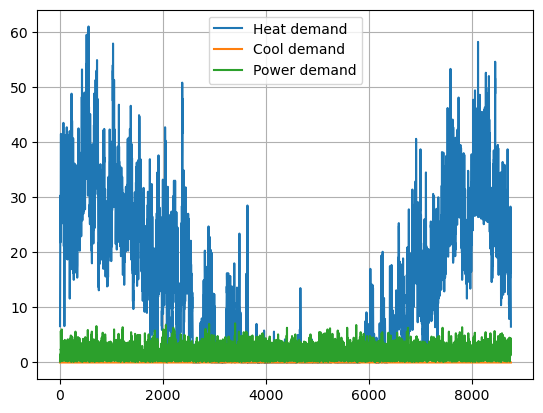

Total pv yield per year per m2:  217.59551407684873


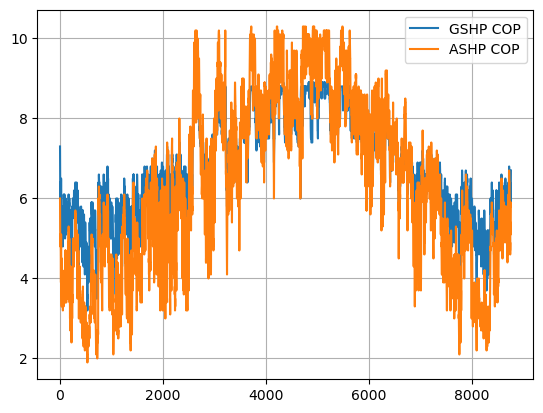

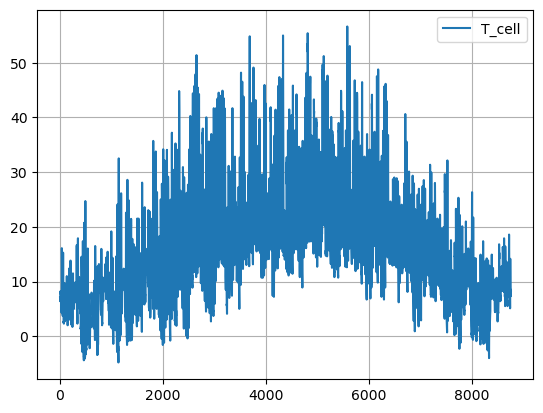

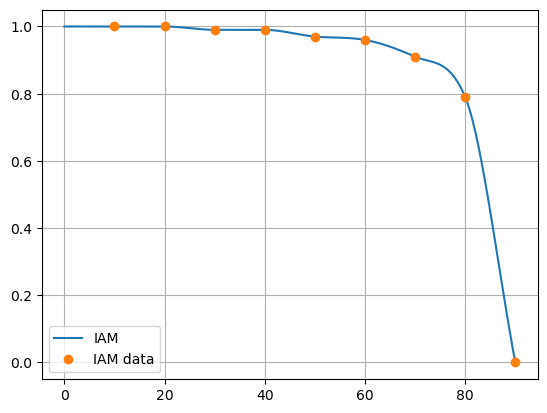

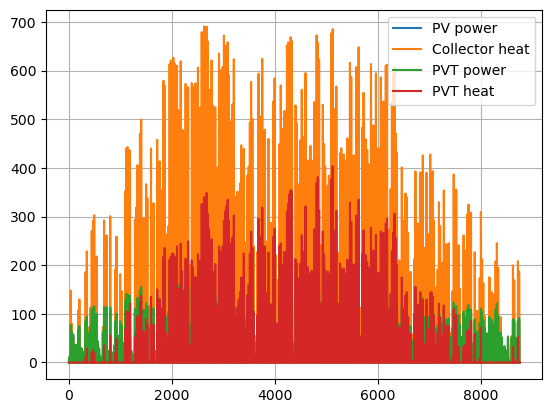

In [4]:
## Set the borefield parameters
# Load parameters
param, devs, dem, result_dict = load_params.load_params()

In [5]:
QBorExt = QDemHea*(3/4) / 1000 # kW
QBorInj = QDemCoo / 1000 # kW

# initiate borefield
borefield = ghe.Borefield()

# set ground data in borefield
borefield.set_ground_parameters(devs["Borefield"]["bor_params"]["ground_data"])
borefield.set_fluid_parameters(devs["Borefield"]["bor_params"]["fluid_data"])
borefield.set_pipe_parameters(devs["Borefield"]["bor_params"]["pipe_data"])

borefield.create_rectangular_borefield(N_1=devs["Borefield"]["bor_params"]["N_1"], N_2=devs["Borefield"]["bor_params"]["N_2"], B_1=devs["Borefield"]["bor_params"]["B"], B_2=devs["Borefield"]["bor_params"]["B"], \
                                            H=100, D=devs["Borefield"]["bor_params"]["D"], r_b=devs["Borefield"]["bor_params"]["r_b"])

# set temperature bounds
borefield.set_max_avg_fluid_temperature(devs["Borefield"]["bor_params"]["Tf_max"])
borefield.set_min_avg_fluid_temperature(devs["Borefield"]["bor_params"]["Tf_min"])

# load the hourly profile
borefield.simulation_period = devs["Borefield"]["bor_params"]["lifetime"]
load = ghe.HourlyGeothermalLoad(simulation_period=devs["Borefield"]["bor_params"]["lifetime"])

load.hourly_extraction_load = QBorExt 
load.hourly_injection_load = QBorInj
borefield.load = load
load.all_months_equal = True

colors = plt.cm.tab10(np.linspace(0, 1, 10))
Tb_GHE_monthly = {}
Tf_GHE_monthly = {}
Tb_GHE_hourly_ST = {}
Tf_GHE_hourly_ST = {}

## options without short-term effects
options = {"disp": False, "profiles": True, "method": "equivalent"}
## set options
borefield.set_options_gfunction_calculation(options)

L = borefield.size_L4()
print("L: ", L)

L:  121.46974004003823


In [6]:
## Write kappa and rCel recors for modelica
devs["Borefield"]["bor_params"]["H"] = L # m, depth of the boreholes


# Load aggregation parameters
tLoaAgg = 3600
nCel = 1 # Modelica default is: nCel = 5
lvlBas = 2 # Modelica default is: lvlBas = 2
timFin = devs["Borefield"]["bor_params"]["timFin"]  # s, final time of the g-function calculation

# Create borefield object
bf = Borefield(devs["Borefield"]["bor_params"])

# Calculate the g-function
bf.calculate_g_function()
timSer = np.column_stack((devs["Borefield"]["bor_params"]["time_gfunc"], devs["Borefield"]["bor_params"]["Tstep_gfunc"]))
i = bf.countAggregationCells(lvlBas=lvlBas, nCel=nCel, timFin=timFin, tLoaAgg=tLoaAgg)
nu, rCel = bf.aggregationCellTimes(i, lvlBas, nCel, tLoaAgg, timFin)
kappa = bf.aggregationWeightingFactors(i, len(devs["Borefield"]["bor_params"]["Tstep_gfunc"]), timSer, nu)

# Write kappa and rCel records
path = r'C:\Workdir\Develop\IOCS\Cases\ThreeHouses\Ideal_OCP'
bf.write_rCel_record(rCel, path, name="RCel_ThreeHouses_3X2_190m")
bf.write_kappa_record(kappa, path, name="Kappa_ThreeHouses_3X2_190m")
